### Homework 5 - advanced macroeconomics 1

**Task 2**: After we finish the estimation part of the course. Pick data on real GDP from some country (annual data). You will have to filter the data to obtain the cyclical component. Estimate the process for TFP. Do all the tasks in estimation: priors check, identification, convergence, and compute the Bayesian IRFs.

In this script i will make the first part of the task until the estimation of the process for TFP. From that i will work on DYNARE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
pib = pd.read_csv('ipeadata_pibreal2010.csv')
print(pib)

     Data  \
0    1900   
1    1901   
2    1902   
3    1903   
4    1904   
..    ...   
119  2019   
120  2020   
121  2021   
122  2022   
123  2023   

     PIB - preços de mercado (preços 2010) - R$ de 2010 - Instituto Brasileiro de Geografia e Estatística- Sistema de Contas Nacionais (IBGE/SCN Anual) - SCN10_PIBP10  \
0                                         2.170338e+04                                                                                                                   
1                                         2.482099e+04                                                                                                                   
2                                         2.470108e+04                                                                                                                   
3                                         2.518072e+04                                                                                                             

In [7]:
pib.dtypes

Data                                                                                                                                                                   int64
PIB - preços de mercado (preços 2010) - R$ de 2010 - Instituto Brasileiro de Geografia e Estatística- Sistema de Contas Nacionais (IBGE/SCN Anual) - SCN10_PIBP10    float64
Unnamed: 2                                                                                                                                                           float64
dtype: object

In [11]:
pib.columns = ['Ano', 'PIB', 'Descartar']    # renomeia a segunda coluna como pib

pib['Ano'] = pd.to_datetime(pib['Ano'], format='%Y')  # Converte a coluna dos anos para datetime

pib = pib.drop(columns=['Descartar'])

# Reorganizando e definindo o índice como a data
pib = pib.set_index('Ano')

print(pib.head())

                     PIB
Ano                     
1900-01-01  21703.379822
1901-01-01  24820.992393
1902-01-01  24701.084217
1903-01-01  25180.716921
1904-01-01  25540.441448


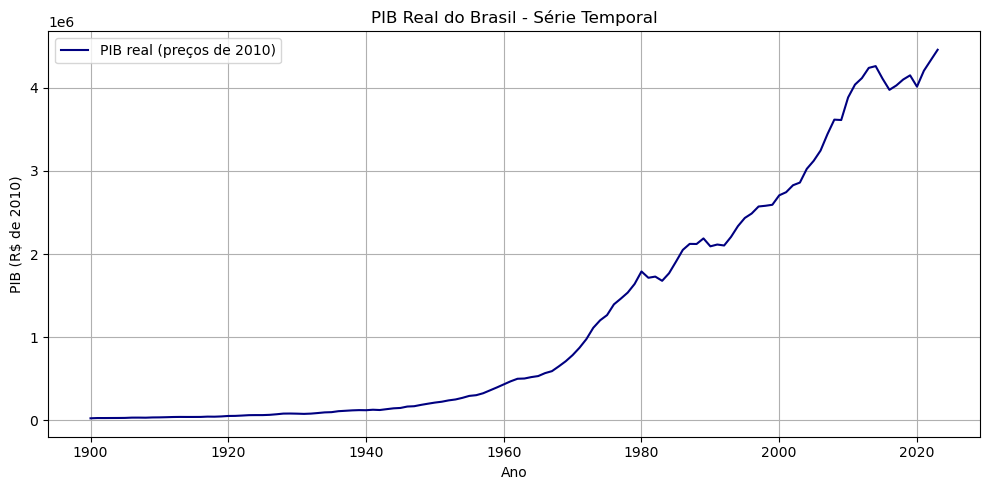

In [17]:
# plot 
plt.figure(figsize=(10, 5))
plt.plot(pib.index, pib['PIB'], label='PIB real (preços de 2010)', color='navy')
plt.title('PIB Real do Brasil - Série Temporal')
plt.xlabel('Ano')
plt.ylabel('PIB (R$ de 2010)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

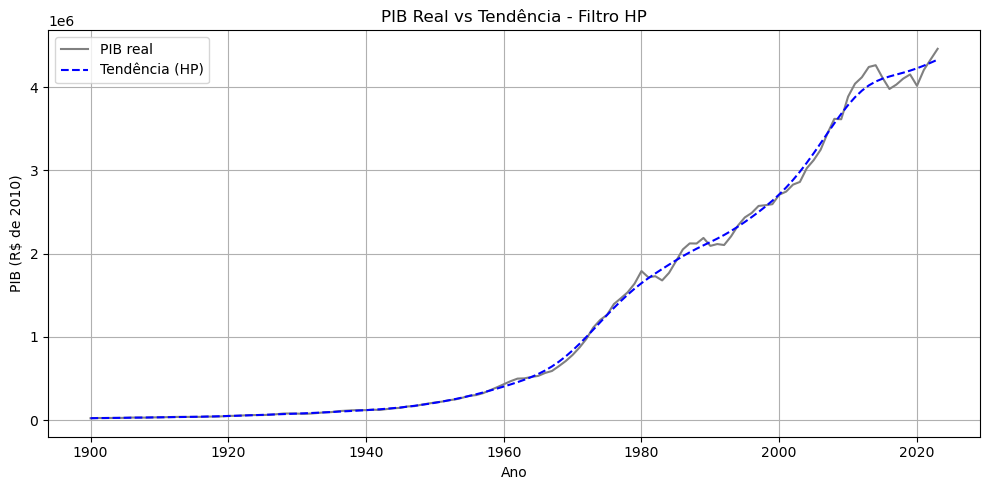

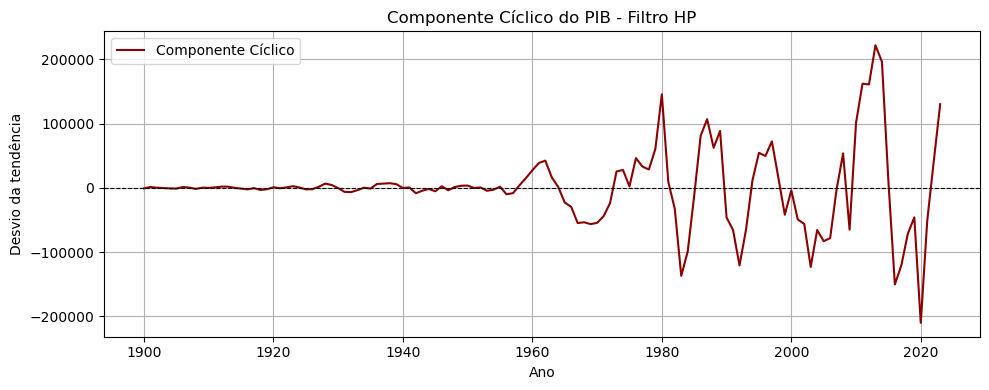

In [19]:
from statsmodels.tsa.filters.hp_filter import hpfilter

# Aplica o filtro HP à série do PIB
cycle, trend = hpfilter(pib['PIB'], lamb=100)  # lambda=100 para dados anuais

# Adiciona as colunas ao DataFrame
pib['PIB_tendencia'] = trend
pib['PIB_ciclo'] = cycle

# tendência vs PIB
plt.figure(figsize=(10, 5))
plt.plot(pib.index, pib['PIB'], label='PIB real', color='gray')
plt.plot(pib.index, pib['PIB_tendencia'], label='Tendência (HP)', color='blue', linestyle='--')
plt.title('PIB Real vs Tendência - Filtro HP')
plt.xlabel('Ano')
plt.ylabel('PIB (R$ de 2010)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# parte cíclica
plt.figure(figsize=(10, 4))
plt.plot(pib.index, pib['PIB_ciclo'], label='Componente Cíclico', color='darkred')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Componente Cíclico do PIB - Filtro HP')
plt.xlabel('Ano')
plt.ylabel('Desvio da tendência')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Preparing the data

pib['log_PIB'] = np.log(pib['PIB'])      # Aplica log no PIB antes do filtro HP

cycle, trend = hpfilter(pib['log_PIB'], lamb=100)   # Reaplica o filtro HP no log do PIB
pib['TFP'] = cycle                 # Essa será a proxy de a_t

In [28]:
print(pib)

                     PIB  PIB_tendencia      PIB_ciclo    log_PIB       TFP
Ano                                                                        
1900-01-01  2.170338e+04   2.238058e+04    -677.201624   9.985223 -0.041550
1901-01-01  2.482099e+04   2.337238e+04    1448.616475  10.119445  0.054606
1902-01-01  2.470108e+04   2.435740e+04     343.685843  10.114602  0.012114
1903-01-01  2.518072e+04   2.534336e+04    -162.646041  10.133834 -0.006019
1904-01-01  2.554044e+04   2.634142e+04    -800.979241  10.148018 -0.029166
...                  ...            ...            ...        ...       ...
2019-01-01  4.151725e+06   4.197607e+06  -45882.285619  15.239034 -0.012023
2020-01-01  4.015683e+06   4.225610e+06 -209927.820255  15.205718 -0.051633
2021-01-01  4.206934e+06   4.257829e+06  -50895.812842  15.252245 -0.012361
2022-01-01  4.333844e+06   4.293062e+06   40781.733874  15.281965  0.009415
2023-01-01  4.459893e+06   4.329598e+06  130295.007047  15.310635  0.029842

[124 rows x

In [34]:
# saving the cycle as TFP to import in octave
# pib[['TFP']].to_csv('tfp_brasil.csv')

In [36]:
print(len(pib))

124


In [38]:
pib = pib.rename(columns={'TFP': 'a'})  # renomeia para o nome usado no .mod
pib['date'] = pib.index                 # se a data está no índice
print(pib)

                     PIB  PIB_tendencia      PIB_ciclo    log_PIB         a  \
Ano                                                                           
1900-01-01  2.170338e+04   2.238058e+04    -677.201624   9.985223 -0.041550   
1901-01-01  2.482099e+04   2.337238e+04    1448.616475  10.119445  0.054606   
1902-01-01  2.470108e+04   2.435740e+04     343.685843  10.114602  0.012114   
1903-01-01  2.518072e+04   2.534336e+04    -162.646041  10.133834 -0.006019   
1904-01-01  2.554044e+04   2.634142e+04    -800.979241  10.148018 -0.029166   
...                  ...            ...            ...        ...       ...   
2019-01-01  4.151725e+06   4.197607e+06  -45882.285619  15.239034 -0.012023   
2020-01-01  4.015683e+06   4.225610e+06 -209927.820255  15.205718 -0.051633   
2021-01-01  4.206934e+06   4.257829e+06  -50895.812842  15.252245 -0.012361   
2022-01-01  4.333844e+06   4.293062e+06   40781.733874  15.281965  0.009415   
2023-01-01  4.459893e+06   4.329598e+06  130295.0070

In [40]:
# Salvando com o nome e formato corretos
# pib[['date', 'a']].to_csv('tfp_brasil.csv', index=False)